In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [34]:
# Import Dataset (use ../ because notebook lives in notebooks/)
df = pd.read_csv(r'..\data\raw\adult_income.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [35]:
df['income'].unique()

<StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str

In [36]:
# Clean Dataset Income Column
df['income'] = df['income'].str.replace('.', '', regex=False)
df['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [37]:
df['education'].unique()
df['education'].value_counts()


education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

In [38]:
# Collapase Categories for easier interpretation 
education_map = {
    'Preschool': 'Before HS',
    '1st-4th': 'Before HS',
    '5th-6th': 'Before HS',
    '7th-8th': 'Before HS',
    '9th': 'Before HS',
    '10th': 'Before HS',
    '11th': 'Before HS',

    '12th': 'High School',
    'HS-grad': 'High School',

    'Some-college': 'Some College',
    'Assoc-acdm': 'Some College',
    'Assoc-voc': 'Some College',

    'Bachelors': 'Bachelors',
    'Masters': 'Masters',
    'Doctorate': 'Doctorate',
    'Prof-school': 'Professional'
}

df['education_grouped'] = df['education'].map(education_map)


In [39]:
df['education_grouped'].value_counts()


education_grouped
High School     16441
Some College    14540
Bachelors        8025
Before HS        5751
Masters          2657
Professional      834
Doctorate         594
Name: count, dtype: int64

In [40]:
# Basic Statistical Analysis
#
# Chi Square Tests 
# Question: Does income category differ by education attainment?
# Columns: Outcome (Income), Rows: Explanatory (Education groups)
contingency = pd.crosstab(
    df['education_grouped'],
    df['income']
)

contingency


income,<=50K,>50K
education_grouped,,
Bachelors,4712,3313
Before HS,5433,318
Doctorate,163,431
High School,13890,2551
Masters,1198,1459
Professional,217,617
Some College,11542,2998


## Correlation Matrix

Examine linear relationships between all numeric variables.
A high positive/negative correlation between a feature and `income_binary`
suggests the feature is a strong linear predictor of income.

In [ ]:
numeric_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

df_corr = df[numeric_cols].copy()
df_corr['income_binary'] = (df['income'] == '>50K').astype(int)

corr = df_corr.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

print("\nCorrelations with income (>50K = 1):")
print(corr['income_binary'].drop('income_binary').sort_values(ascending=False).to_string())

In [41]:
# Run Chi Square Test of independence
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4e}")

Chi-square statistic: 6444.92
Degrees of freedom: 6
P-value: 0.0000e+00


In [42]:
df['marital-status'].unique()

<StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

In [43]:
# Collapse groups for easier interpretation 
marital_map = {
    'Never-married': 'Never Married',

    'Married-civ-spouse': 'Married',
    'Married-AF-spouse': 'Married',

    'Divorced': 'Previously Married',
    'Separated': 'Previously Married',
    'Widowed': 'Previously Married',
    'Married-spouse-absent': 'Previously Married'
}

df['marital_grouped'] = df['marital-status'].map(marital_map)
df['marital_grouped'].value_counts()

marital_grouped
Married               22416
Never Married         16117
Previously Married    10309
Name: count, dtype: int64

In [44]:
contingency_M_I = pd.crosstab(
    df['marital_grouped'],
    df['income']
)

contingency_M_I

income,<=50K,>50K
marital_grouped,,
Married,12418,9998
Never Married,15384,733
Previously Married,9353,956


In [45]:
# Run Chi Square Test of independence
chi2, p, dof, expected = chi2_contingency(contingency_M_I)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4e}")

Chi-square statistic: 9805.30
Degrees of freedom: 2
P-value: 0.0000e+00


In [46]:
# Finds proportion of each group
prop_table = contingency_M_I.div(contingency_M_I.sum(axis=1), axis=0)
prop_table

income,<=50K,>50K
marital_grouped,,
Married,0.553979,0.446021
Never Married,0.954520,0.045480
Previously Married,0.907265,0.092735


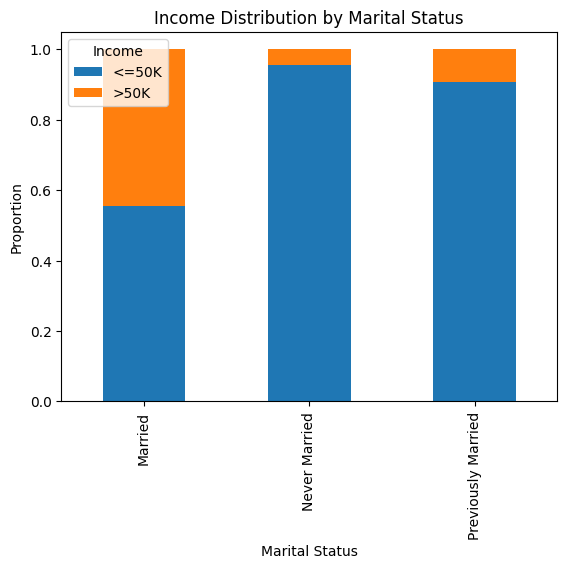

In [47]:
prop_table.plot(kind='bar', stacked=True)

plt.ylabel('Proportion')
plt.xlabel('Marital Status')
plt.title('Income Distribution by Marital Status')
plt.legend(title='Income')
plt.show()


In [48]:
df['native-country'].unique()
df['native-country'].value_counts()


native-country
United-States                 43832
Mexico                          951
?                               583
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

## Chi-Square Tests for Remaining Categorical Variables

In [49]:
def run_chi2(df, col, target='income', label=None):
    """Run chi-square test and print results. Returns dict of stats."""
    label = label or col
    ct = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"--- {label} vs {target} ---")
    print(f"  Chi-square: {chi2:,.2f}   dof: {dof}   p-value: {p:.4e}\n")
    return {'variable': label, 'chi2': chi2, 'dof': dof, 'p_value': p}

In [50]:
# Chi-square: Workclass vs Income
chi2_results = []

chi2_results.append(run_chi2(df, 'education_grouped', label='Education (grouped)'))
chi2_results.append(run_chi2(df, 'marital_grouped', label='Marital Status (grouped)'))
chi2_results.append(run_chi2(df, 'workclass'))
chi2_results.append(run_chi2(df, 'occupation'))
chi2_results.append(run_chi2(df, 'sex'))
chi2_results.append(run_chi2(df, 'race'))
chi2_results.append(run_chi2(df, 'relationship'))

--- Education (grouped) vs income ---
  Chi-square: 6,444.92   dof: 6   p-value: 0.0000e+00

--- Marital Status (grouped) vs income ---
  Chi-square: 9,805.30   dof: 2   p-value: 0.0000e+00

--- workclass vs income ---
  Chi-square: 1,457.36   dof: 8   p-value: 2.2363e-309

--- occupation vs income ---
  Chi-square: 5,788.35   dof: 14   p-value: 0.0000e+00

--- sex vs income ---
  Chi-square: 2,248.85   dof: 1   p-value: 0.0000e+00

--- race vs income ---
  Chi-square: 487.03   dof: 4   p-value: 4.2844e-104

--- relationship vs income ---
  Chi-square: 10,088.72   dof: 5   p-value: 0.0000e+00



In [51]:
# Summary table of all chi-square tests
chi2_summary = pd.DataFrame(chi2_results)
chi2_summary['significant'] = chi2_summary['p_value'] < 0.05
chi2_summary

,variable,chi2,dof,p_value,significant
0,Education (grouped),6444.916428,6,0.000000e+00,True
1,Marital Status (grouped),9805.302035,2,0.000000e+00,True
2,workclass,1457.360043,8,2.236332e-309,True
3,occupation,5788.348532,14,0.000000e+00,True
4,sex,2248.847679,1,0.000000e+00,True
5,race,487.026287,4,4.284378e-104,True
6,relationship,10088.722490,5,0.000000e+00,True


## ANOVA Tests for Continuous Variables

Compare means of continuous variables across income groups (<=50K vs >50K).

In [52]:
from scipy.stats import f_oneway
import numpy as np

low = df[df['income'] == '<=50K']
high = df[df['income'] == '>50K']

continuous_vars = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

anova_results = []
for var in continuous_vars:
    f_stat, p_val = f_oneway(low[var].dropna(), high[var].dropna())
    print(f"--- ANOVA: {var} by income ---")
    print(f"  <=50K mean: {low[var].mean():.2f}   >50K mean: {high[var].mean():.2f}")
    print(f"  F-statistic: {f_stat:,.2f}   p-value: {p_val:.4e}\n")
    anova_results.append({
        'variable': var,
        'mean_low': low[var].mean(),
        'mean_high': high[var].mean(),
        'F_statistic': f_stat,
        'p_value': p_val,
    })

--- ANOVA: age by income ---
  <=50K mean: 36.87   >50K mean: 44.28
  F-statistic: 2,737.21   p-value: 0.0000e+00

--- ANOVA: hours-per-week by income ---
  <=50K mean: 38.84   >50K mean: 45.45
  F-statistic: 2,670.36   p-value: 0.0000e+00

--- ANOVA: capital-gain by income ---
  <=50K mean: 147.01   >50K mean: 4042.24
  F-statistic: 2,556.18   p-value: 0.0000e+00

--- ANOVA: capital-loss by income ---
  <=50K mean: 54.15   >50K mean: 193.53
  F-statistic: 1,087.03   p-value: 8.5436e-236



In [53]:
# Summary table of all ANOVA tests
anova_summary = pd.DataFrame(anova_results)
anova_summary['significant'] = anova_summary['p_value'] < 0.05
anova_summary

,variable,mean_low,mean_high,F_statistic,p_value,significant
0,age,36.872184,44.275178,2737.207112,0.000000e+00,True
1,hours-per-week,38.840048,45.452896,2670.362124,0.000000e+00,True
2,capital-gain,147.010308,4042.239497,2556.179071,0.000000e+00,True
3,capital-loss,54.151931,193.528964,1087.027570,8.543599e-236,True


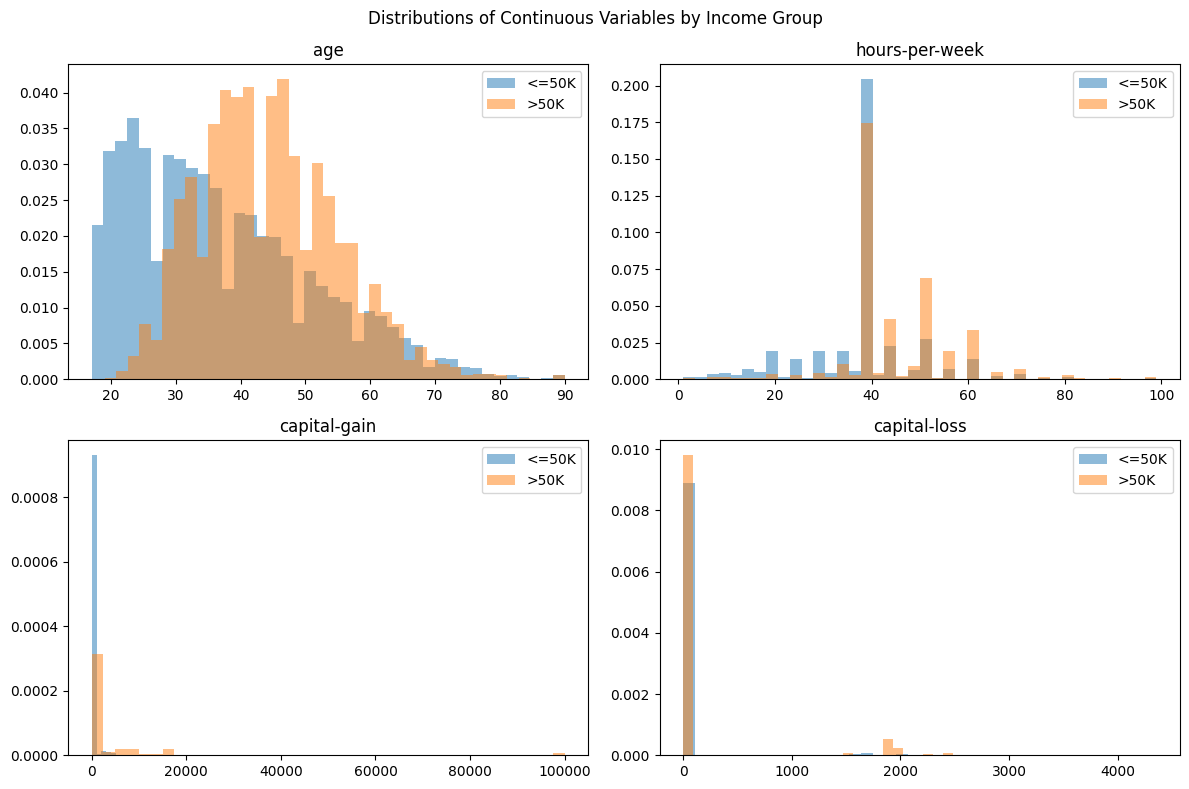

In [54]:
# Visualize continuous variable distributions by income group
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, continuous_vars):
    ax.hist(low[var].dropna(), bins=40, alpha=0.5, label='<=50K', density=True)
    ax.hist(high[var].dropna(), bins=40, alpha=0.5, label='>50K', density=True)
    ax.set_title(var)
    ax.legend()
plt.suptitle('Distributions of Continuous Variables by Income Group')
plt.tight_layout()
plt.show()